- Figure 4 C,D, E

In [2]:
import os
from pathlib import Path
import warnings
import random
warnings.filterwarnings('ignore')

import scanpy as sc
import numpy as np
import pandas as pd
import decoupler as dc

import mplscience
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

import gseapy as gp
import blitzgsea as blitz

seed = 777

In [ ]:
def do_pseudobulk(adata, condition, contrast=None, seed=seed):
    if condition not in adata.obs.columns:
        raise ValueError(f"Condition '{condition}' not found in adata.obs")
    if contrast and contrast not in adata.obs.columns:
        raise ValueError(f"Contrast '{contrast}' not found in adata.obs")
        
    pseudobulk = []
    random.seed(seed)
    
    for sample in adata.obs.sample_id.unique():
        sample_cells = adata[adata.obs['sample_id'] == sample]
        
        # Create 3 pseudo-replicates
        idx = np.array_split(
            np.random.permutation(sample_cells.obs_names), 
            3
        )
        
        for i, split_idx in enumerate(idx):
            if len(split_idx) == 0:
                continue
                
            rep_adata = sc.AnnData(
                X=sample_cells[split_idx].X.sum(axis=0),
                var=sample_cells.var
            )
            rep_adata.obs_names = [f"{sample}-{i}"]
            rep_adata.obs['condition'] = sample_cells.obs[condition].iloc[0]
            rep_adata.obs['replicate'] = i
            
            if contrast:
                rep_adata.obs[contrast] = (
                    sample_cells.obs[contrast].mean() 
                    if pd.api.types.is_numeric_dtype(sample_cells.obs[contrast])
                    else sample_cells.obs[contrast].iloc[0]
                )
                
            pseudobulk.append(rep_adata)
    
    pb = sc.concat(pseudobulk)
    
    # DESeq2 analysis
    design_factors = [x for x in [contrast, 'condition'] if x is not None]
    dds = DeseqDataSet(
        counts=pd.DataFrame(pb.X, columns=pb.var_names),
        metadata=pb.obs,
        design_factors=design_factors,
        refit_cooks=True,
        inference=DefaultInference(),
        n_cpus=None
    )
    
    sc.pp.filter_genes(dds, min_cells=1)
    dds.deseq2()
    
    # Visualization
    sc.tl.pca(dds, layer="normed_counts")
    fig = sc.pl.pca(dds, color='condition', size=200, show=False)
    
    # Differential expression
    stat_res = DeseqStats(dds, inference=DefaultInference())
    stat_res.summary()
    
    return pb, dds, stat_res.results_df, fig

In [4]:
msigdb = dc.get_resource('MSigDB', organism = 'mouse')

In [5]:
collections = msigdb['collection'].unique()
for idx, collection in enumerate(collections, 1):
    print(f"{idx}. {collection}")

# hallmark
# kegg_pathways
# go_biological_process
# reactome_pathways

## additional
# oncogenic_signatures
# cell_type_signatures = annotation?
# cancer_modules

1. chemical_and_genetic_perturbations
2. immunesigdb
3. mirna_targets_mirdb
4. go_molecular_function
5. tf_targets_gtrf
6. tf_targets_legacy
7. oncogenic_signatures
8. cell_type_signatures
9. vaccine_response
10. go_biological_process
11. cancer_gene_neighborhoods
12. cancer_modules
13. go_cellular_component
14. wikipathways
15. reactome_pathways
16. hallmark
17. mirna_targets_legacy
18. biocarta_pathways
19. positional
20. human_phenotype_ontology
21. pid_pathways
22. kegg_pathways


In [6]:
query = 'hallmark'
db = msigdb[msigdb['collection']==query]

db = db[~db.duplicated(['geneset', 'genesymbol'])]
db.dropna(inplace = True)

# 1. Fig 4e

In [7]:
adata = sc.read_h5ad('../output/annotated_redo_2025.h5ad')
adata = adata[adata.obs['cell_type'] == 'OPC'].copy()
adata.obs['condition'] = adata.obs['sample_id'].apply(lambda x: 'Tumor' if x.startswith('Mouse') else 'Normal')
adata.obs.condition = adata.obs.condition.astype('category')
# cond = ((adata.obs['GFP'] == 'GFP+') & (adata.obs.condition == 'Tumor')) | ((adata.obs['GFP'] == 'GFP-') & (adata.obs.condition == 'Normal'))
adata = adata[:, adata.var_names != 'Cas9-EGFP'].copy()
# adata = adata[cond].copy()
sc.pp.filter_genes(adata, min_cells = int(adata.shape[0]*0.1))
adata

AnnData object with n_obs × n_vars = 10783 × 9585
    obs: 'sample_id', 'sample_info', 'age', 'sex', 'barcode', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'scDblFinder_score', 'scDblFinder_class', 'doublet_score', 'predicted_doublet', 'cell_type', 'grade', 'GFP', 'leiden_res1', 'wb_anno', 'wb_conf_score', 'cellid_prediction', 'leiden_res2', 'new_cell_type', 'old_cell_type', 'leiden', 'predicted_labels', 'conf_score', 'each_cell_type', 'condition'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'n_cells'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'neighbors', 'sample_info_colors', 'umap'
    obsm: 'X_scANVI', 'X_scVI', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'log1p'
    obsp: 'connectivities', 'distances'

In [8]:
adata.obs.condition.value_counts()

condition
Normal    9758
Tumor     1025
Name: count, dtype: int64

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 0.41 seconds.

Fitting dispersion trend curve...
... done in 0.09 seconds.

Fitting MAP dispersions...
... done in 0.48 seconds.

Fitting LFCs...
... done in 0.27 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 2 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: condition Tumor vs Normal
                  baseMean  log2FoldChange     lfcSE      stat        pvalue  \
0610009B22Rik    36.865098        0.675638  0.190161  3.552975  3.809006e-04   
0610009L18Rik    14.133449        0.298370  0.262313  1.137459  2.553466e-01   
0610010K14Rik    35.535389        0.382675  0.211313  1.810933  7.015122e-02   
0610030E20Rik    19.800088        0.193412  0.143674  1.346183  1.782434e-01   
0610040J01Rik   120.525786       -0.682565  0.151859 -4.494739  6.965518e-06   
...                    ...             ...       ...       ...           ...   
mt-Nd3          234.969673       -1.438548  0.330149 -4.357273  1.316932e-05   
mt-Nd4         1319.933221       -0.625445  0.224369 -2.787575  5.310416e-03   
mt-Nd4l         111.400064       -2.023549  0.219470 -9.220152  2.966794e-20   
mt-Nd5          155.374597       -0.513928  0.110034 -4.670621  3.002901e-06   
mt-Nd6           26.705014        0.236394  0.191999  1.

... done in 0.25 seconds.



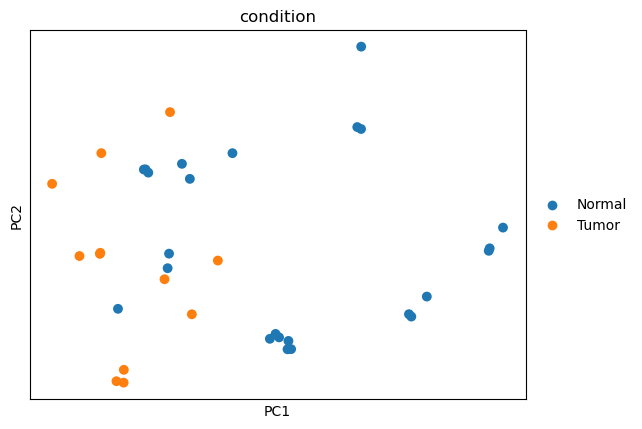

In [8]:
pb, dds, de, fig = do_pseudobulk(adata, 'condition', seed= 777)

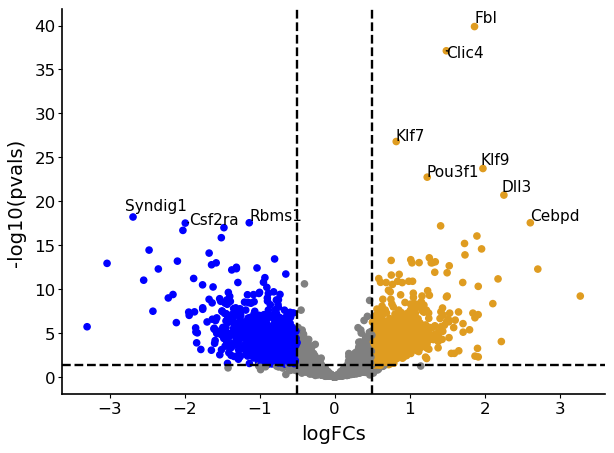

In [11]:
with mplscience.style_context():
    dc.plot_volcano_df(de, x='log2FoldChange', y='padj', top = 10,
                       color_pos = '#DF9C20',
                       color_neg = '#0000FF',)
    # plt.savefig(os.path.join('plot/', 'reFig4e_normalOPCvstumorOPC.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.savefig(os.path.join('plot/', 'Fig4e_normalOPCvstumorOPC.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')

## ORA

In [11]:
db['geneset'] = db['geneset'].apply(
    lambda x: x.split('_', 1)[1] if isinstance(x, str) and '_' in x else x
)

In [12]:
top_genes = de[de['padj'] < 0.05].copy()

enriched = dc.get_ora_df(df = top_genes, net = db, source = 'geneset', target = 'genesymbol')
enriched.head()

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features
0,ADIPOGENESIS,171,0.321637,0.000821,0.006840,1.505838,10.699335,Abcb8;Adipor2;Ak2;Aldh2;Atp1b3;Bcl6;Cat;Cd151;...
1,ALLOGRAFT_REJECTION,174,0.172414,0.934995,0.995702,0.808440,0.054338,Ache;Acvr2a;Akt1;B2m;Bcat1;Bcl10;Ccnd2;Ccnd3;D...
2,ANDROGEN_RESPONSE,95,0.326316,0.008158,0.037083,1.532071,7.367323,Abcc4;Acsl3;Adamts1;Akap12;Akt1;Appbp2;B2m;Ccn...
3,ANGIOGENESIS,33,0.121212,0.946399,0.995702,0.621960,0.034264,App;Ccnd2;Itgav;Pdgfa
4,APICAL_JUNCTION,163,0.276074,0.040139,0.111499,1.292410,4.155608,Actg1;Adam23;Akt3;Atp1a3;Baiap2;Bmp1;Cadm3;Cdh...


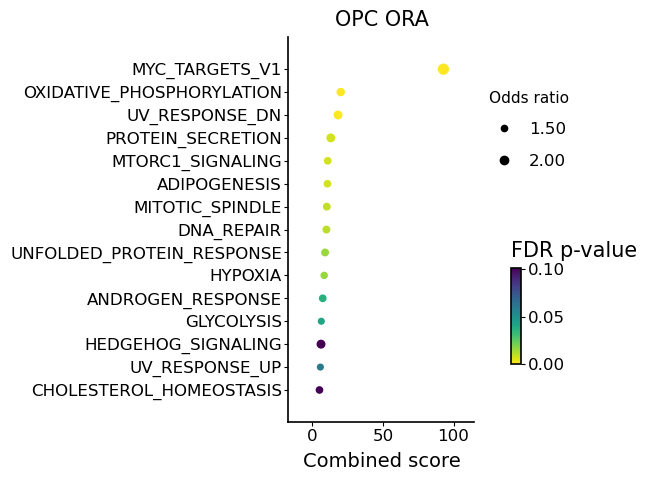

In [13]:
with mplscience.style_context():
    dc.plot_dotplot(
        enriched.sort_values('Combined score', ascending=False).head(15),
        x='Combined score',
        y='Term',
        s='Odds ratio',
        c='FDR p-value',
        scale=0.5,
        title= "OPC ORA"
    )
    plt.grid(False)


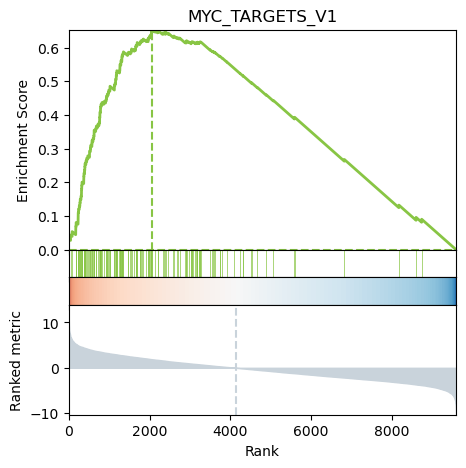

In [14]:
dc.plot_running_score(
    df=de,
    stat='stat',
    net=db,
    source='geneset',
    target='genesymbol',
    set_name='MYC_TARGETS_V1'
)

## GSEA

In [20]:
de['rank'] = -np.log10(de.padj) * de.log2FoldChange
de = de.sort_values('rank', ascending=False)
de['gene'] = de.index

In [21]:
rnk = de[['gene', 'rank']].reset_index(drop=True).copy()

In [22]:
gene_sets = db[['geneset', 'genesymbol']].groupby('geneset').agg(lambda x: x.tolist()).to_dict()['genesymbol']
gene_sets = {k: v for k, v in gene_sets.items() if v}

In [23]:
res = blitz.gsea(rnk, gene_sets)

In [29]:
res['Term'] = res.index
res['NES'] = res['nes']
res['num_genes_in_set'] = res.leading_edge.str.split(',').apply(lambda x: len(x))
res['log(1/FDR)'] = -np.log10(res['fdr'])
res['% Genes in set'] = (res['num_genes_in_set'] / res['geneset_size'] * 100).astype(int)

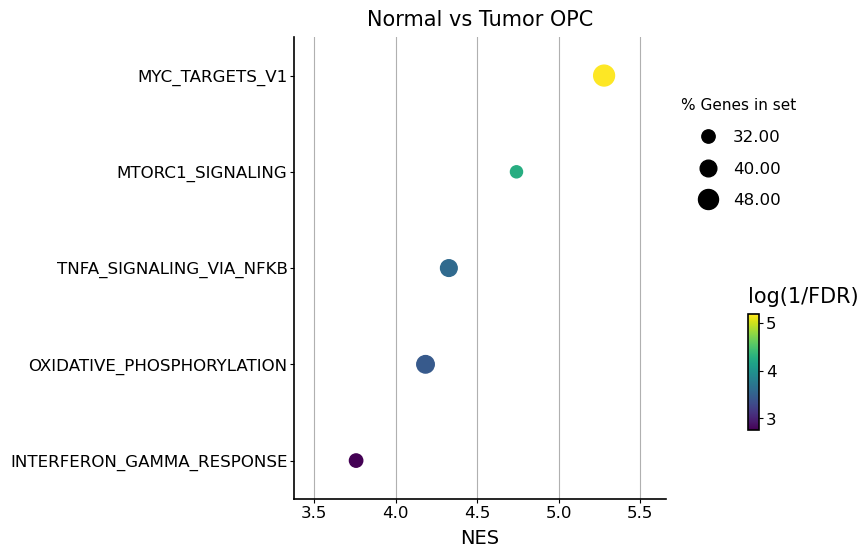

In [30]:
with mplscience.style_context():
    dc.plot_dotplot(res.iloc[:5,:], x = 'NES', y = 'Term', c = 'log(1/FDR)',  s = '% Genes in set', title = "Normal vs Tumor OPC", cmap = 'viridis', figsize = (6, 6), scale = 0.05, save = 'plot/Fig4e_GSEA_normalOPCvstumorOPC.pdf')

# 2 - 2. Fig 4f : OPC vs Tumor (in mouse, no GFP filter)

In [11]:
def do_pseudobulk(adata, condition, reference, seed=777):
    pseudobulk = []
    random.seed(seed)
    
    # Process each condition separately
    for cond in adata.obs[condition].unique():
        # Get subset for this condition
        condition_subset = adata[adata.obs[condition] == cond]
        
        # Process each sample within this condition
        for sample in condition_subset.obs.sample_id.unique():
            sample_subset = condition_subset[condition_subset.obs['sample_id'] == sample]
            
            # Create random splits
            idx = list(sample_subset.obs_names)
            random.shuffle(idx)
            idx = np.array_split(np.array(idx), 3)
            
            # Create pseudobulk replicates
            for i, split_idx in enumerate(idx):
                if len(split_idx) > 0:  # Only create replicate if cells exist
                    rep_adata = sc.AnnData(X=sample_subset[split_idx].X.sum(axis=0).reshape(1,-1),
                                         var=sample_subset.var)
                    rep_adata.obs_names = [f"{sample}-{cond}-{i}"]
                    rep_adata.obs['condition'] = cond
                    rep_adata.obs['replicate'] = i
                    rep_adata.obs['sample_id'] = sample
                    pseudobulk.append(rep_adata)
    
    pb = sc.concat(pseudobulk)
    counts_df = pd.DataFrame(pb.X, columns=pb.var_names)
    
    dds = DeseqDataSet(
        counts=counts_df,
        metadata=pb.obs,
        design_factors=['condition'],
        ref_level=['condition', reference],
        refit_cooks=True,
        inference=DefaultInference(),
        n_cpus=None
    )
    
    sc.pp.filter_genes(dds, min_cells=1)
    dds.deseq2()
    sc.tl.pca(dds, layer="normed_counts")
    fig = sc.pl.pca(dds, color='condition', size=200, show=False)
    
    stat_res = DeseqStats(dds, inference=DefaultInference())
    stat_res.summary()
    
    return dds, stat_res.results_df, fig

In [12]:
adata = sc.read_h5ad('../output/annotated_redo_2025.h5ad')
adata = adata[adata.obs['cell_type'].isin(['OPC', 'Tumor']) & adata.obs.sample_id.isin(['Mouse1', 'Mouse2', 'Mouse3', 'Mouse4'])].copy()
adata.obs.cell_type = adata.obs.cell_type.cat.remove_unused_categories()
adata.obs.cell_type = adata.obs.cell_type.cat.reorder_categories(['OPC', 'Tumor'])
adata = adata[:, adata.var_names != 'Cas9-EGFP'].copy()
sc.pp.filter_genes(adata, min_cells = int(adata.shape[0]*0.1))
adata

AnnData object with n_obs × n_vars = 17802 × 10597
    obs: 'sample_id', 'sample_info', 'age', 'sex', 'barcode', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'scDblFinder_score', 'scDblFinder_class', 'doublet_score', 'predicted_doublet', 'cell_type', 'grade', 'GFP', 'leiden_res1', 'wb_anno', 'wb_conf_score', 'cellid_prediction', 'leiden_res2', 'new_cell_type', 'old_cell_type', 'leiden', 'predicted_labels', 'conf_score', 'each_cell_type'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'n_cells'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'neighbors', 'sample_info_colors', 'umap'
    obsm: 'X_scANVI', 'X_scVI', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'log1p'
    obsp: 'connectivities', 'distances'

In [13]:
adata.obs.cell_type.value_counts()

cell_type
Tumor    16777
OPC       1025
Name: count, dtype: int64

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.47 seconds.

Fitting dispersion trend curve...
... done in 0.12 seconds.

Fitting MAP dispersions...
... done in 0.46 seconds.

Fitting LFCs...
... done in 0.40 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 12 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: condition Tumor vs OPC
                  baseMean  log2FoldChange     lfcSE      stat        pvalue  \
0610009B22Rik    85.509831       -0.524460  0.184605 -2.840981  4.497504e-03   
0610010K14Rik   105.687789        0.566369  0.113808  4.976545  6.472926e-07   
0610030E20Rik    47.573290       -0.070582  0.147185 -0.479543  6.315522e-01   
0610040J01Rik   141.575134       -1.273846  0.175019 -7.278320  3.380032e-13   
1110002L01Rik    18.018715        0.718258  0.199422  3.601705  3.161366e-04   
...                    ...             ...       ...       ...           ...   
mt-Nd3          266.374508        0.250298  0.131268  1.906769  5.655047e-02   
mt-Nd4         2311.112342        0.272066  0.084141  3.233471  1.222959e-03   
mt-Nd4l          92.428740        0.362444  0.244053  1.485104  1.375163e-01   
mt-Nd5          284.175325        0.149709  0.095824  1.562337  1.182087e-01   
mt-Nd6           58.791411       -0.482512  0.252057 -1.914

... done in 0.28 seconds.



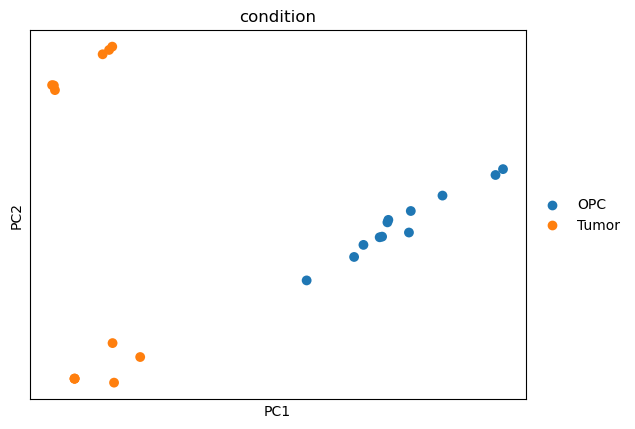

In [14]:
dds, de, fig = do_pseudobulk(adata, 'cell_type', 'OPC')

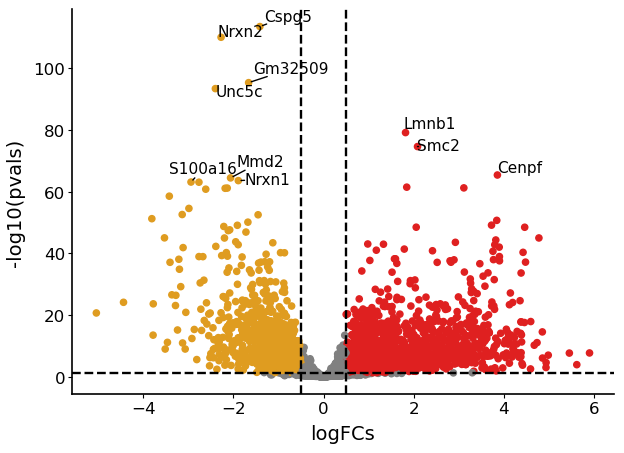

In [15]:
with mplscience.style_context():
    dc.plot_volcano_df(de, x='log2FoldChange', y='padj', top = 10,
                       color_pos = '#DF2020',
                       color_neg = '#DF9C20' )
    # plt.savefig(os.path.join('plot/', 'Fig4f_OPCvsTumor.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.savefig(os.path.join('plot/', 'reFig4f_OPCvsTumor.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')

## ORA

In [59]:
top_genes = de[de['padj'] < 0.05].copy()

enriched = dc.get_ora_df(df = top_genes, net = db, source = 'geneset', target = 'genesymbol')
enriched.head()

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features
0,ADIPOGENESIS,171,0.327485,0.051671,0.103342,1.227384,3.636563,Abca1;Acox1;Agpat3;Ak2;Aldoa;Apoe;Arl4a;Atp1b3...
1,ALLOGRAFT_REJECTION,174,0.195402,0.990552,0.999786,0.733437,0.006963,Abce1;B2m;Brca1;Ccnd2;Ccnd3;Cdkn2b;Csk;Degs1;E...
2,ANDROGEN_RESPONSE,95,0.368421,0.021238,0.048268,1.384753,5.334031,Abcc4;Abhd2;Actn1;Adrm1;Akap12;Arid5b;B2m;Bmpr...
3,ANGIOGENESIS,33,0.212121,0.823540,0.999786,0.832232,0.161572,Ccnd2;Fstl1;Itgav;Jag1;Lrpap1;Nrp1;Tnfrsf21
4,APICAL_JUNCTION,163,0.300613,0.202576,0.316524,1.126907,1.799267,Actg1;Actn1;Adam15;Adam23;Adamts5;Arpc2;Atp1a3...


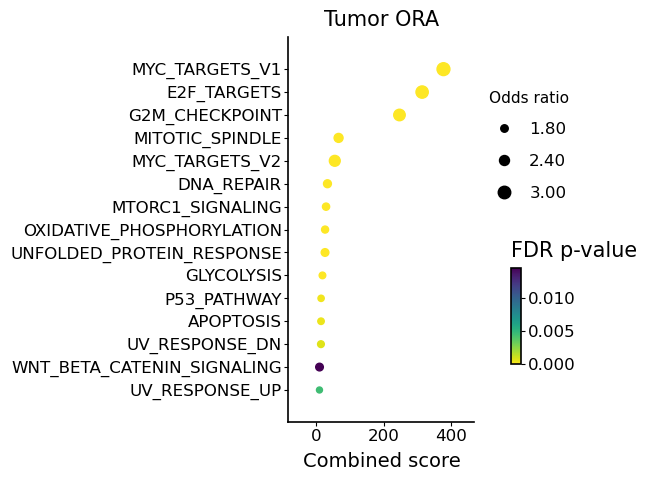

In [60]:
with mplscience.style_context():
    dc.plot_dotplot(
        enriched.sort_values('Combined score', ascending=False).head(15),
        x='Combined score',
        y='Term',
        s='Odds ratio',
        c='FDR p-value',
        scale=0.5,
        title= "Tumor ORA"
    )
    plt.grid(False)


## GSEA

In [50]:
query = 'hallmark'
db = msigdb[msigdb['collection']==query]

db = db[~db.duplicated(['geneset', 'genesymbol'])]
db.dropna(inplace = True)

In [51]:
db['geneset'] = db['geneset'].apply(
    lambda x: x.split('_', 1)[1] if isinstance(x, str) and '_' in x else x
)

In [52]:
de['rank'] = -np.log10(de.padj) * de.log2FoldChange
de = de.sort_values('rank', ascending=False)
de['gene'] = de.index

In [53]:
rnk = de[['gene', 'rank']].reset_index(drop=True).copy()

In [54]:
gene_sets = db[['geneset', 'genesymbol']].groupby('geneset').agg(lambda x: x.tolist()).to_dict()['genesymbol']
gene_sets = {k: v for k, v in gene_sets.items() if v}

In [55]:
res = blitz.gsea(rnk, gene_sets)

In [56]:
res['Term'] = res.index
res['NES'] = res['nes']
res['num_genes_in_set'] = res.leading_edge.str.split(',').apply(lambda x: len(x))
res['log(1/FDR)'] = -np.log10(res['fdr'])
res['% Genes in set'] = (res['num_genes_in_set'] / res['geneset_size'] * 100).astype(int)

In [59]:
res[res['fdr'] < 0.05].iloc[]

,es,nes,pval,sidak,fdr,geneset_size,leading_edge,Term,NES,num_genes_in_set,log(1/FDR),% Genes in set
Term,,,,,,,,,,,,
E2F_TARGETS,0.904455,5.022726,5.094325e-07,0.000025,0.000017,170,"Pa2g4,Ssrp1,Hmgb2,Cdca8,Cdc20,Top2a,Rfc3,Cks2,...",E2F_TARGETS,5.022726,89,4.776566,52
G2M_CHECKPOINT,0.898138,4.970123,6.691047e-07,0.000033,0.000017,169,"Ube2c,Cdc20,Top2a,Cks2,Smc2,Ccna2,Cenpa,Nusap1...",G2M_CHECKPOINT,4.970123,77,4.776566,45
MYC_TARGETS_V1,0.833527,4.444869,8.794537e-06,0.000440,0.000147,173,"Pa2g4,Cdc20,Ccna2,Rpl34,Kpnb1,Tfdp1,Eif4e,Rack...",MYC_TARGETS_V1,4.444869,104,3.833938,60
MITOTIC_SPINDLE,0.854801,3.988875,6.638736e-05,0.003314,0.000830,127,"Top2a,Nusap1,Lmnb1,Cdk1,Racgap1,Smc4,Ect2,Ezr,...",MITOTIC_SPINDLE,3.988875,27,3.081005,21


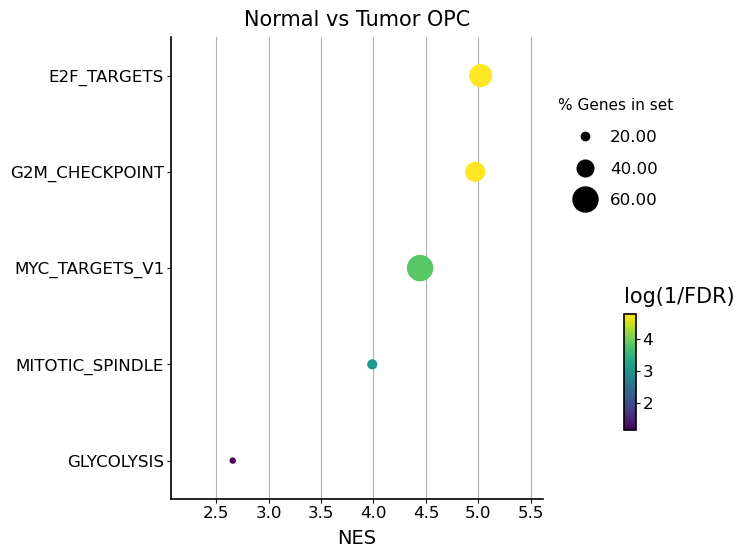

In [57]:
with mplscience.style_context():
    dc.plot_dotplot(res.iloc[:5,:], x = 'NES', y = 'Term', c = 'log(1/FDR)',  s = '% Genes in set', title = "Normal vs Tumor OPC", cmap = 'viridis', figsize = (6, 6), scale = 0.05, save = 'plot/Fig4f_GSEA_OPCvsTumor.pdf')

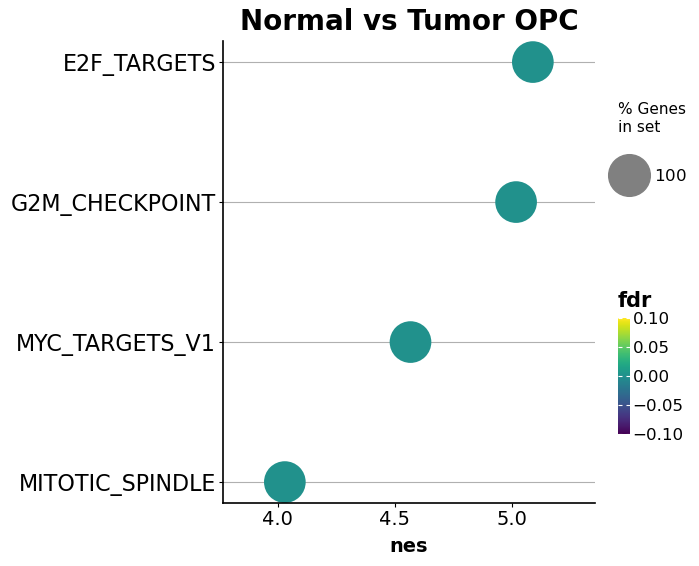

In [116]:

# with mplscience.style_context():
#     gp.dotplot(res, x = 'nes', y = 'Term', column = 'fdr', title = "Normal vs Tumor OPC", cmap = 'viridis', figsize = (6, 6), top_term=10)
#     plt.savefig(os.path.join('../plot', 'Fig4f_OPCvsTumor.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')

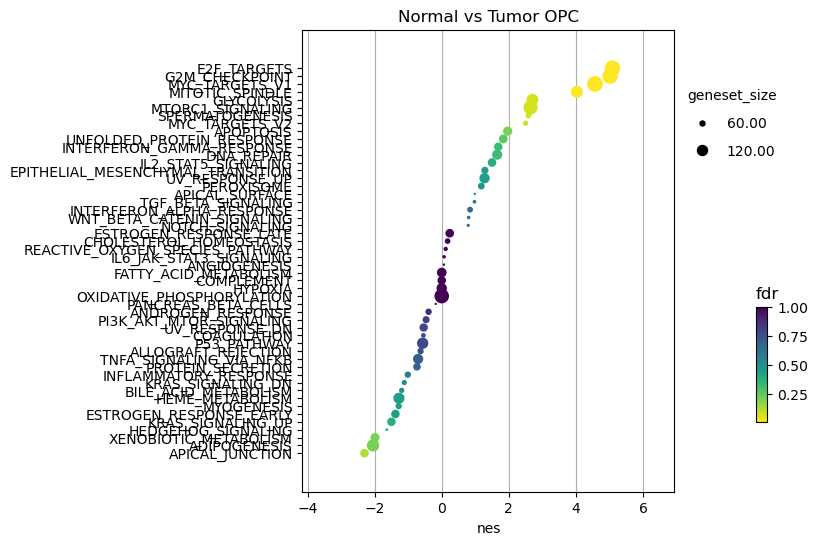

In [ ]:
dc.plot_d